# Fashion-MNIST practice — Colab-ready notebook



In [ ]:
# Cell 1 — imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense


In [ ]:
# Cell 2 — load and prepare the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1], add channel dimension (grayscale) => shape (28,28,1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = np.expand_dims(x_train, axis=-1)  # (N,28,28,1)
x_test  = np.expand_dims(x_test, axis=-1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

# Optionally create a validation split
val_split = 0.1
val_count = int(len(x_train) * val_split)
x_val = x_train[-val_count:]
y_val = y_train_cat[-val_count:]
x_train = x_train[:-val_count]
y_train_cat = y_train_cat[:-val_count]

print('Train:', x_train.shape, y_train_cat.shape)
print('Val:  ', x_val.shape, y_val.shape)
print('Test: ', x_test.shape, y_test_cat.shape)


Train: (54000, 28, 28, 1) (54000, 10)
Val:   (6000, 28, 28, 1) (6000, 10)
Test:  (10000, 28, 28, 1) (10000, 10)


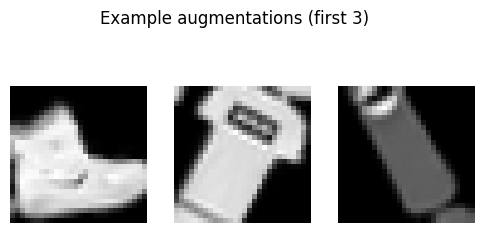

In [ ]:
# Cell 3 — data augmentation (compatible: tries direct layers.* API first)
import tensorflow as tf
from tensorflow.keras import layers

# Detect whether preprocessing layers live directly under layers (newer TF)
if hasattr(layers, "RandomFlip"):
    RF = layers.RandomFlip
    RR = layers.RandomRotation
    RZ = layers.RandomZoom
else:
    # older placement (some TF builds)
    RF = tf.keras.layers.experimental.preprocessing.RandomFlip
    RR = tf.keras.layers.experimental.preprocessing.RandomRotation
    RZ = tf.keras.layers.experimental.preprocessing.RandomZoom

data_augmentation = tf.keras.Sequential([
    RF("horizontal"),
    RR(0.08),
    RZ(0.07),
], name='data_augmentation')

# quick demo (runs only in training mode)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.suptitle('Example augmentations (first 3)')
for i in range(3):
    augmented = data_augmentation(tf.expand_dims(x_train[i], axis=0), training=True)
    plt.subplot(1,3,i+1)
    plt.imshow(augmented[0].numpy().squeeze(), cmap='gray')
    plt.axis('off')
plt.show()


In [ ]:
# Cell 4 — build CNN with BatchNormalization
input_shape = (28,28,1)
model = models.Sequential([
    layers.Input(shape=input_shape),

    # Augmentation (runs only in training)
    data_augmentation,

    # First conv block
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Second conv block
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Cell 5 — train
callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 330s 757ms/step - accuracy: 0.6622 - loss: 1.0105 - val_accuracy: 0.6358 - val_loss: 1.0679
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 285s 676ms/step - accuracy: 0.8188 - loss: 0.5045 - val_accuracy: 0.8587 - val_loss: 0.3752
Epoch 3/10
171/422 ━━━━━━━━━━━━━━━━━━━━ 2:43 651ms/step - accuracy: 0.8422 - loss: 0.4397

In [ ]:
# Cell 6 — evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")


NameError: name 'history' is not defined

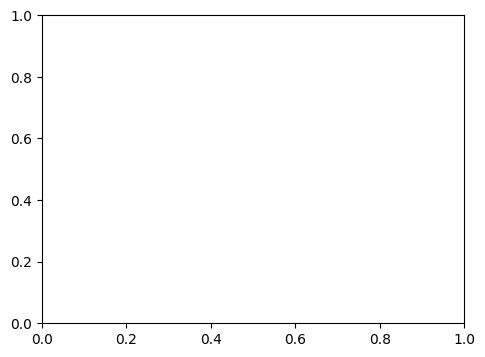

In [ ]:
# Cell 7 — plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('Accuracy')
plt.show()


In [ ]:
# Cell 8 — visualize learned filters from the first Conv2D layer
from tensorflow.keras.layers import Conv2D as KerasConv2D

# Find the first Conv2D layer in the model
first_conv = None
for layer in model.layers:
    if isinstance(layer, KerasConv2D):
        first_conv = layer
        break

if first_conv is None:
    raise RuntimeError("No Conv2D layer found in model")

# Get filters (kernel weights) — shape: (kernel_h, kernel_w, in_channels, out_channels)
filters, biases = first_conv.get_weights()
print("filters shape:", filters.shape)

k_h, k_w, in_ch, out_ch = filters.shape

# Normalize each filter to [0,1] for display and plot the first 16
n_to_show = min(16, out_ch)
plt.figure(figsize=(8,8))
for i in range(n_to_show):
    f = filters[:,:,:,i]  # (k_h,k_w,in_ch)
    f = f.squeeze()
    f_min, f_max = f.min(), f.max()
    if f_max - f_min != 0:
        f_norm = (f - f_min) / (f_max - f_min)
    else:
        f_norm = np.zeros_like(f)
    plt.subplot(4,4,i+1)
    plt.imshow(f_norm, cmap='gray')
    plt.axis('off')
    plt.title(f'F{i}')
plt.suptitle('First conv layer filters (first 16)')
plt.show()


In [ ]:
# Cell 9 — visualize feature maps (activations) for a sample image
import random
idx = random.randint(0, x_test.shape[0]-1)
sample = x_test[idx:idx+1]  # keep batch dim

# Build a model that outputs activations from first few conv layers
layer_outputs = []
for layer in model.layers:
    if isinstance(layer, Conv2D):
        layer_outputs.append(layer.output)
    if len(layer_outputs) >= 4:
        break

activation_model = tf.keras.Model(inputs=model.input, outputs=layer_outputs)
activations = activation_model.predict(sample)

# show activation maps for the first conv layer
first_act = activations[0]  # shape (1, H, W, channels)
n_maps = min(8, first_act.shape[-1])
plt.figure(figsize=(12,3))
for i in range(n_maps):
    plt.subplot(1,n_maps,i+1)
    act = first_act[0,:,:,i]
    act = (act - act.min()) / (act.max() - act.min() + 1e-9)
    plt.imshow(act, cmap='viridis')
    plt.axis('off')
    plt.title(f'Map{i}')
plt.suptitle('Feature maps from first conv layer')
plt.show()

# Also display the input image and its predicted label
pred = model.predict(sample)
pred_label = np.argmax(pred)
true_label = y_test[idx]
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
plt.figure(figsize=(4,4))
plt.imshow(sample[0].squeeze(), cmap='gray')
plt.title(f"True: {class_names[true_label]}  Pred: {class_names[pred_label]} ({pred.max():.2f})")
plt.axis('off')
plt.show()
